# Пример использования библиотеки TheoryGamesDL

В этом ноутбуке показано, как использовать библиотеку TheoryGamesDL для моделирования социальных дилемм и применения методов обучения с подкреплением.

In [1]:
# Импортируем необходимые библиотеки
import numpy as np
import matplotlib.pyplot as plt
import json

# Импортируем компоненты нашей библиотеки
from theorygamesdl.models import SocialDilemma
from theorygamesdl.agents import sd_qlearning, HistoryDQNAgent, FullHistoryDQNAgent
from theorygamesdl.utils.simulation import simulate, simulate_neural
from theorygamesdl.utils.encoders import NpEncoder


## Часть 1: Классическое Q-обучение

### Пример 1: Дилемма заключенного

Рассмотрим классическую дилемму заключенного с выплатами [3, 1, 0, 4].

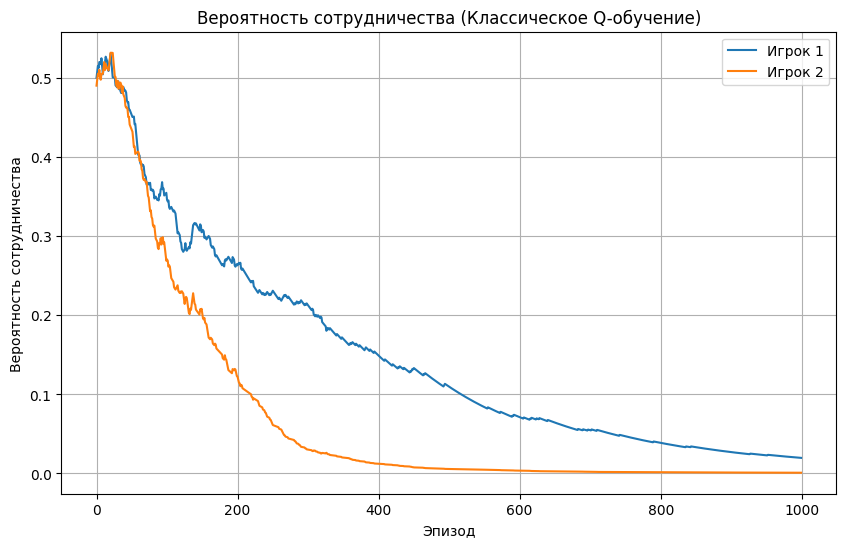

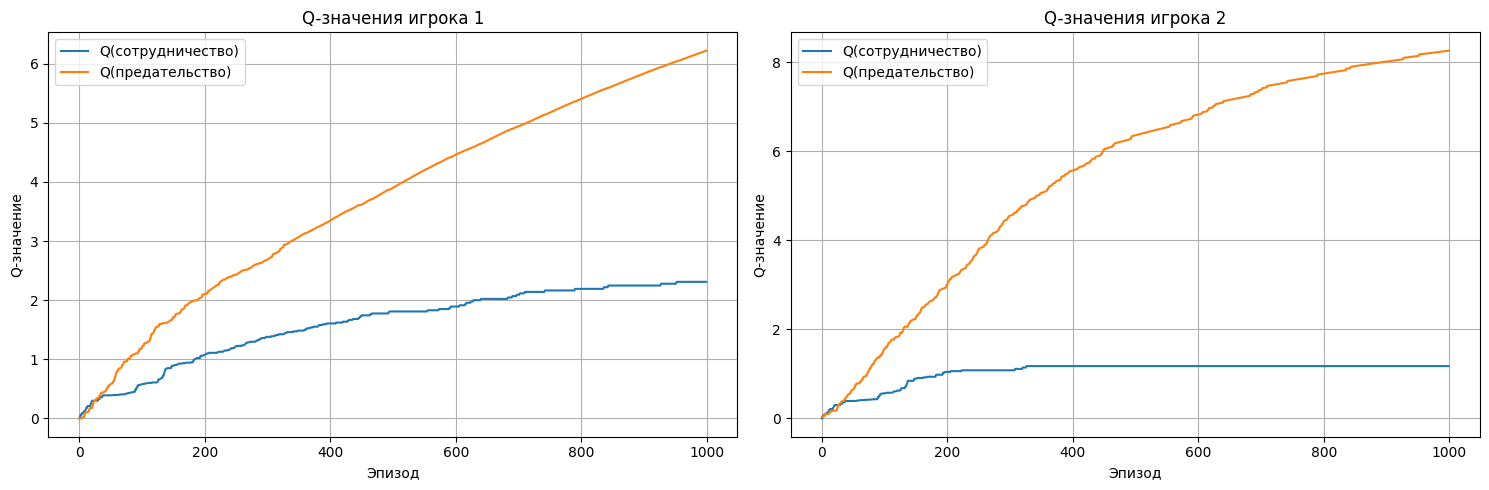

In [2]:
# Запускаем симуляцию дилеммы заключенного
pd_payoffs = [3, 1, 0, 4]  # Выплаты для дилеммы заключенного [CC, DD, DC, CD]
pol1_y1, pol2_y1, q1c, q1d, q2c, q2d, history, h_rew = simulate(
    pd=pd_payoffs, 
    time=1000,  # Количество эпизодов
    gamma=0.9,   # Коэффициент дисконтирования
    alpha=0.01,  # Скорость обучения
    beta=1,      # Параметр температуры для softmax-стратегии
    show_q=True  # Показывать графики Q-значений
)

### Пример 2: Сравнение различных типов социальных дилемм

Рассмотрим четыре классических типа социальных дилемм и сравним поведение агентов в них:

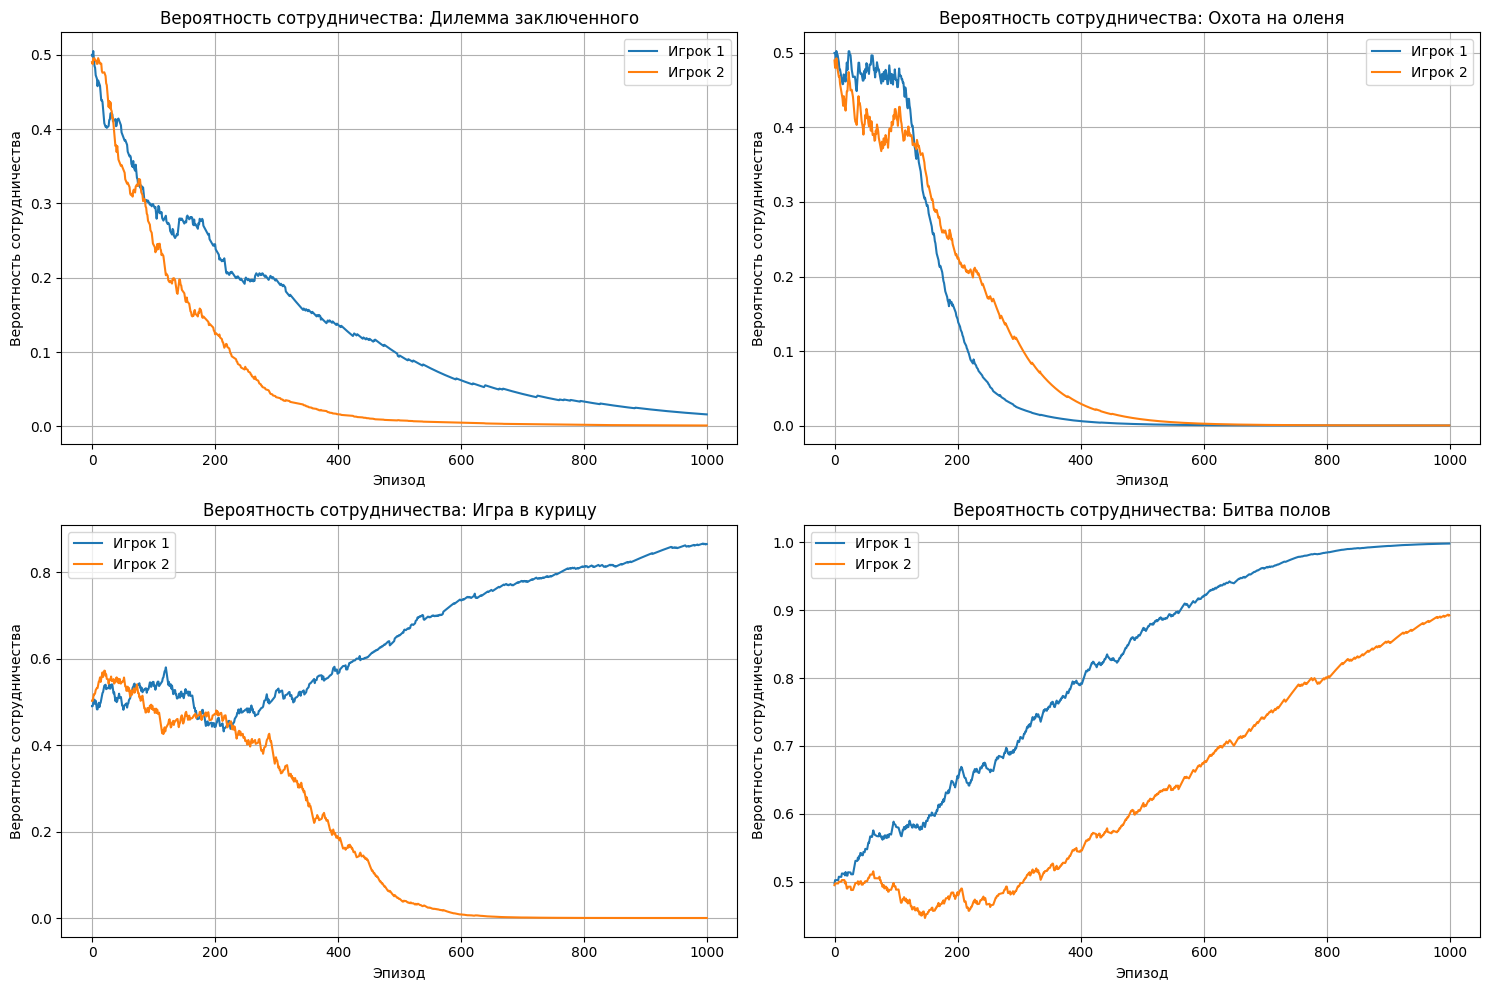

In [3]:
# Создаем и моделируем четыре типа социальных дилемм
dilemma_types = ['pd', 'sh', 'ch', 'bs']  # Дилемма заключенного, Охота на оленя, Игра в курицу, Битва полов
dilemma_names = ['Дилемма заключенного', 'Охота на оленя', 'Игра в курицу', 'Битва полов']

# Создаем списки для хранения результатов
all_pol1 = []
all_pol2 = []

# Моделируем каждую дилемму
for dilemma_type in dilemma_types:
    # Создаем игру
    game = SocialDilemma(dilemma_type=dilemma_type, steps_number=1)
    
    # Запускаем Q-обучение
    pol1, pol2, payoff_matrix1, payoff_matrix2, errs, history, Q1, Q2, h_rew = sd_qlearning(
        game, 
        episode_count=1000, 
        alpha=0.01, 
        gamma=0.9, 
        beta=1
    )
    
    # Преобразуем формат политик для анализа
    pol1 = np.moveaxis(pol1, 0, 1)
    pol2 = np.moveaxis(pol2, 0, 1)
    
    # Извлекаем вероятности сотрудничества
    pol1_y1 = [row[1] for row in pol1[0]]
    pol2_y1 = [row[1] for row in pol2[0]]
    
    # Сохраняем результаты
    all_pol1.append(pol1_y1)
    all_pol2.append(pol2_y1)

# Визуализируем результаты для всех дилемм
plt.figure(figsize=(15, 10))

for i, (dilemma_name, pol1_y1, pol2_y1) in enumerate(zip(dilemma_names, all_pol1, all_pol2)):
    plt.subplot(2, 2, i+1)
    plt.plot(pol1_y1, label='Игрок 1')
    plt.plot(pol2_y1, label='Игрок 2')
    plt.title(f'Вероятность сотрудничества: {dilemma_name}')
    plt.xlabel('Эпизод')
    plt.ylabel('Вероятность сотрудничества')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# Сохраняем результаты для дальнейшего сравнения
pd_pol1_y1 = all_pol1[0]
pd_pol2_y1 = all_pol2[0]

## Часть 2: Нейросетевые агенты

### Пример 3: Сравнение DQN агентов на разных дилеммах

Посмотрим, как DQN агенты с буфером истории ведут себя в разных типах социальных дилемм.

In [4]:
def smooth(data, window_size=10):
    """Сглаживание с помощью скользящего среднего."""
    if len(data) < window_size:
        return data  # нечего сглаживать
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


In [5]:
# Типы дилемм и их имена
dilemma_types_neural = ['pd', 'sh', 'ch', 'bs']
dilemma_names_neural = ['Дилемма заключенного', 'Охота на оленя', 'Игра в курицу', 'Битва полов']

# --- DQN с короткой историей ---
all_train_probs1_hist = []
all_train_probs2_hist = []

# --- DQN с полной историей ---
all_train_probs1_fullhist = []
all_train_probs2_fullhist = []

for dilemma_type in dilemma_types_neural:
    # history_dqn (теперь с возвратом трейна)
    _, _, train_history, _ = simulate_neural(
        dilemma_type=dilemma_type,
        agent_type="history_dqn",
        episodes=1000,
        eval_episodes=100,
        show_plots=False,
        history_size=1,
        return_train_data=True
    )
    probs1 = [p[0] for p in train_history]
    probs2 = [p[1] for p in train_history]
    all_train_probs1_hist.append(probs1)
    all_train_probs2_hist.append(probs2)

    # full_history_dqn
    _, _, train_history_f, _ = simulate_neural(
        dilemma_type=dilemma_type,
        agent_type="full_history_dqn",
        episodes=1000,
        eval_episodes=100,
        show_plots=False,
        history_size=1,
        return_train_data=True
    )
    probs1_f = [p[0] for p in train_history_f]
    probs2_f = [p[1] for p in train_history_f]
    all_train_probs1_fullhist.append(probs1_f)
    all_train_probs2_fullhist.append(probs2_f)


Обучение Full History DQN: 100%|██████████| 1000/1000 [00:13<00:00, 76.15it/s]


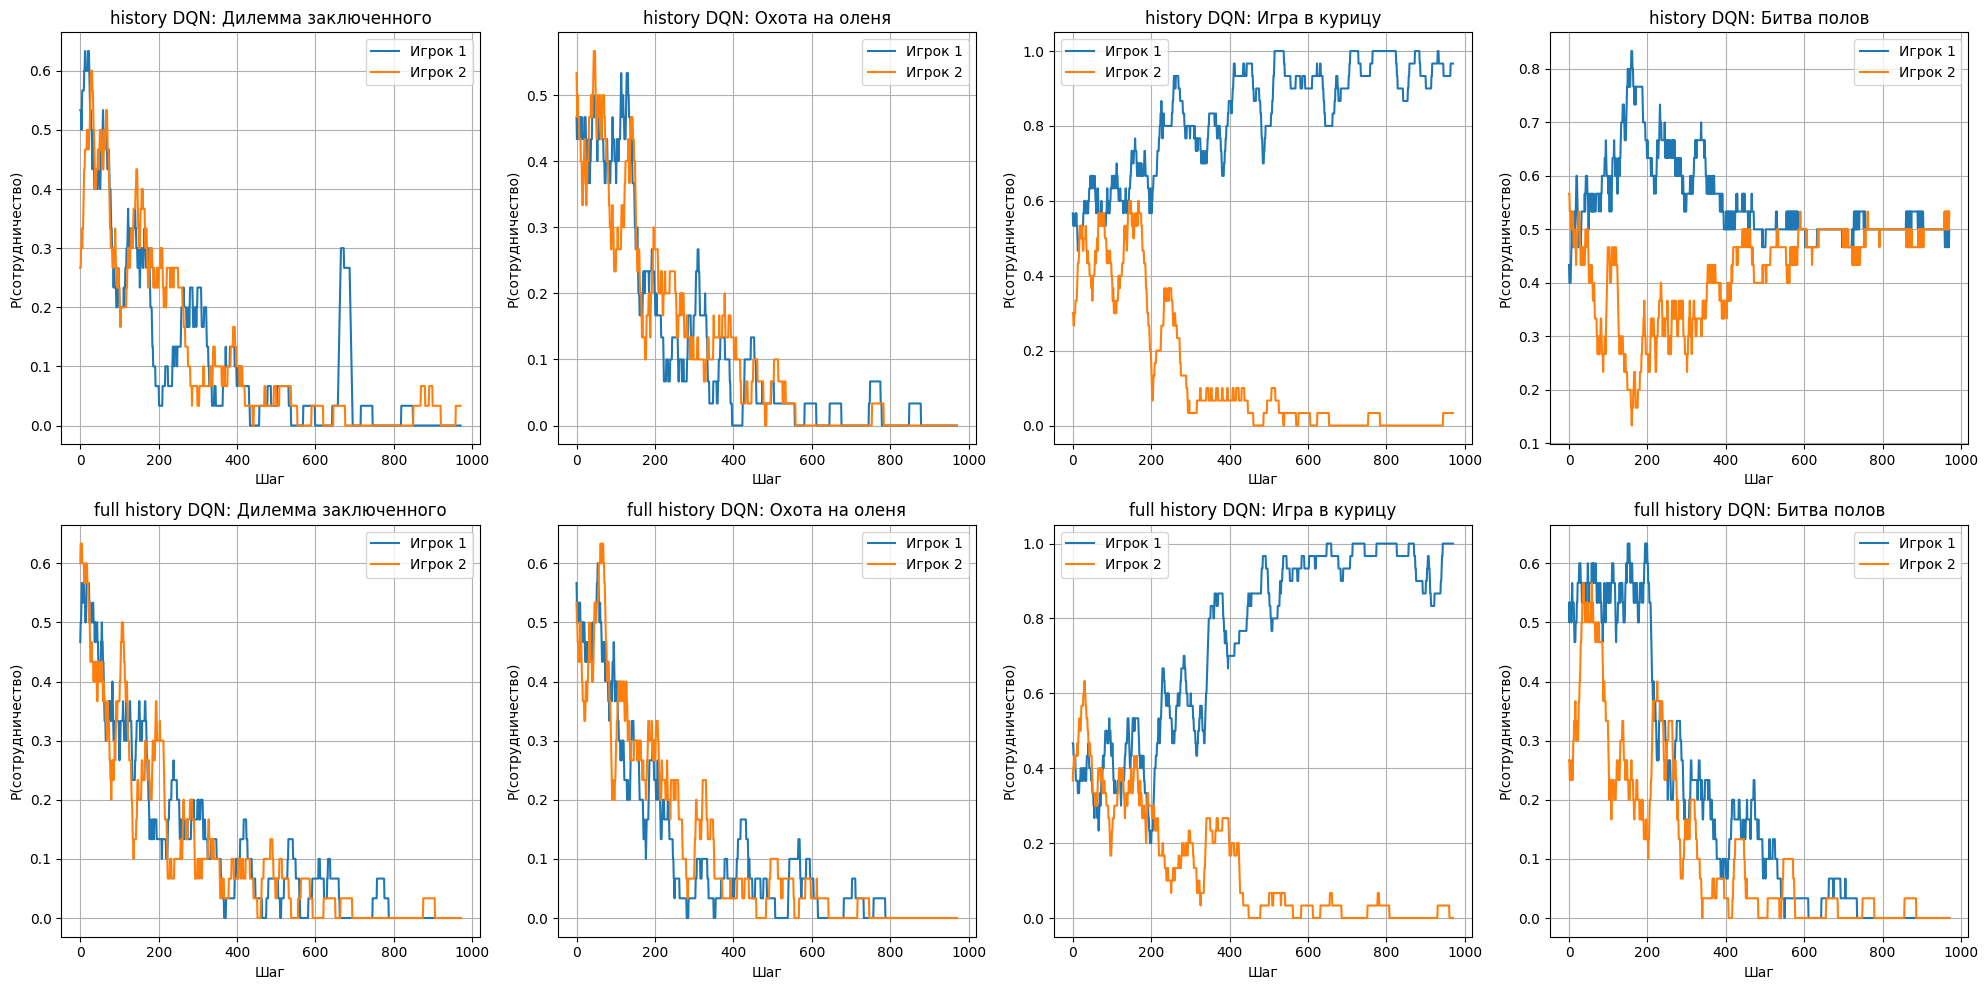

In [6]:

plt.figure(figsize=(20, 10))

for i, name in enumerate(dilemma_names_neural):
    # Сглаженные данные обучения
    smooth_p1_hist = smooth(all_train_probs1_hist[i], window_size=30)
    smooth_p2_hist = smooth(all_train_probs2_hist[i], window_size=30)
    smooth_p1_full = smooth(all_train_probs1_fullhist[i], window_size=30)
    smooth_p2_full = smooth(all_train_probs2_fullhist[i], window_size=30)

    # Верхний ряд: history DQN
    plt.subplot(2, 4, i+1)
    plt.plot(smooth_p1_hist, label='Игрок 1')
    plt.plot(smooth_p2_hist, label='Игрок 2')
    plt.title(f'history DQN: {name}')
    plt.xlabel('Шаг')
    plt.ylabel('P(сотрудничество)')
    plt.legend()
    plt.grid(True)

    # Нижний ряд: full history DQN
    plt.subplot(2, 4, i+5)
    plt.plot(smooth_p1_full, label='Игрок 1')
    plt.plot(smooth_p2_full, label='Игрок 2')
    plt.title(f'full history DQN: {name}')
    plt.xlabel('Шаг')
    plt.ylabel('P(сотрудничество)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


### Пример 4: Сравнение классического Q-обучения и DQN на разных дилеммах

Сравним поведение классического Q-обучения и DQN агентов с историей на всех четырех типах дилемм.

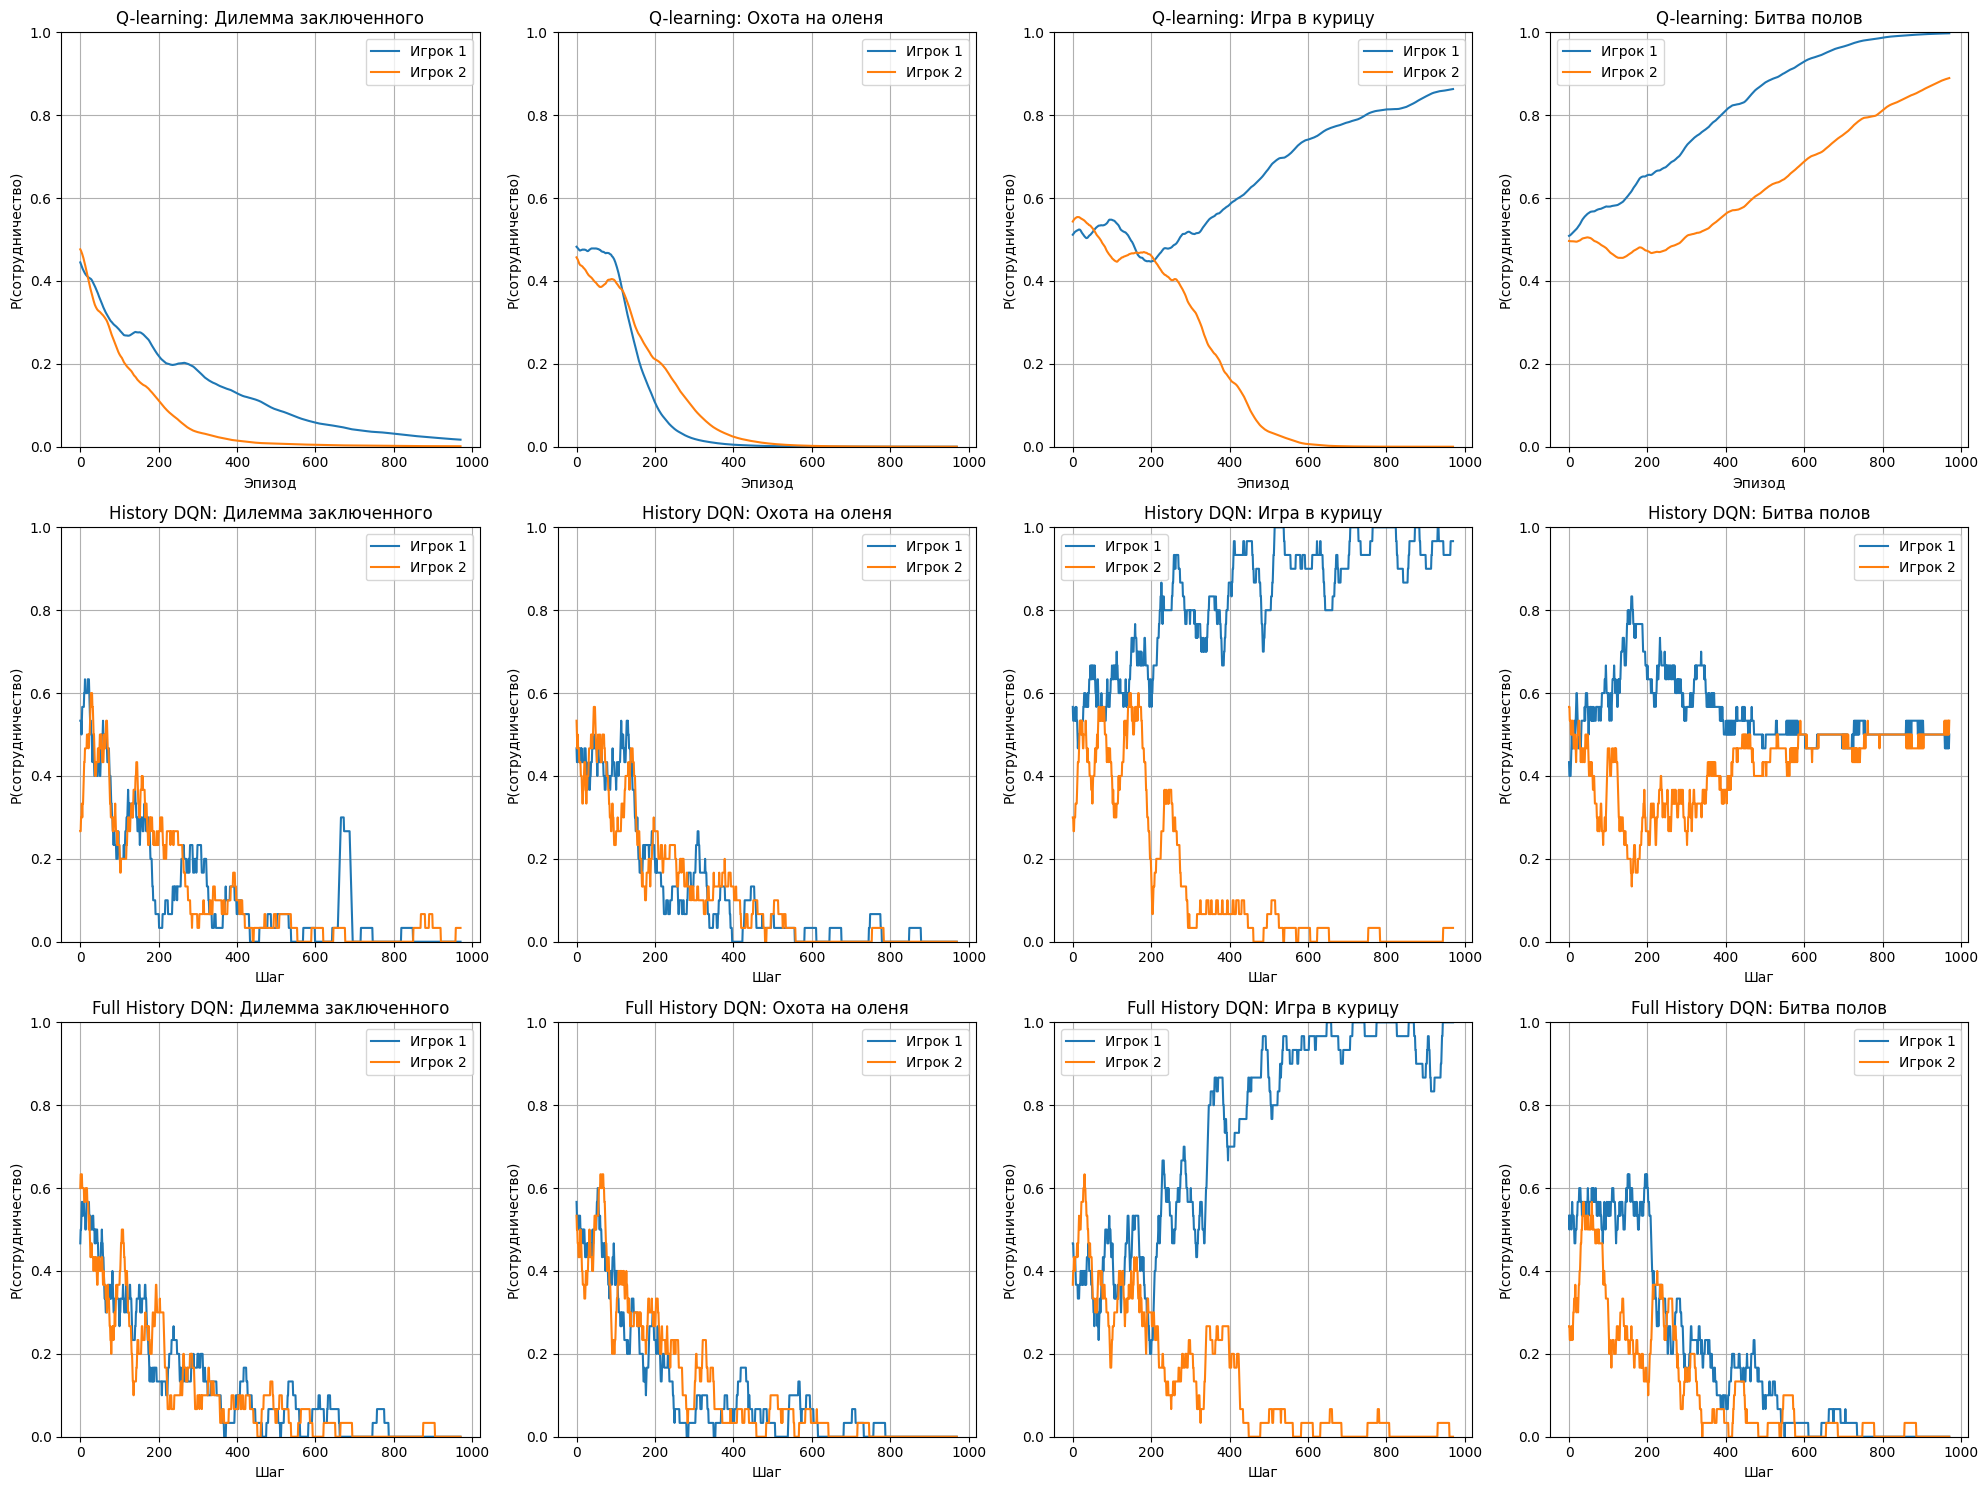

In [7]:
plt.figure(figsize=(20, 15))
n_rows, n_cols = 3, 4  # 3 метода × 4 дилеммы

for i, name in enumerate(dilemma_names):
    # Q-learning (сглаживаем)
    smooth_q_p1 = smooth(all_pol1[i], window_size=30)
    smooth_q_p2 = smooth(all_pol2[i], window_size=30)
    plt.subplot(n_rows, n_cols, 0 * n_cols + i + 1)
    plt.plot(smooth_q_p1, label='Игрок 1')
    plt.plot(smooth_q_p2, label='Игрок 2')
    plt.title(f'Q-learning: {name}')
    plt.xlabel('Эпизод')
    plt.ylabel('P(сотрудничество)')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

    # History DQN (сглаживаем)
    smooth_hist_p1 = smooth(all_train_probs1_hist[i], window_size=30)
    smooth_hist_p2 = smooth(all_train_probs2_hist[i], window_size=30)
    plt.subplot(n_rows, n_cols, 1 * n_cols + i + 1)
    plt.plot(smooth_hist_p1, label='Игрок 1')
    plt.plot(smooth_hist_p2, label='Игрок 2')
    plt.title(f'History DQN: {name}')
    plt.xlabel('Шаг')
    plt.ylabel('P(сотрудничество)')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

    # Full History DQN (сглаживаем)
    smooth_full_p1 = smooth(all_train_probs1_fullhist[i], window_size=30)
    smooth_full_p2 = smooth(all_train_probs2_fullhist[i], window_size=30)
    plt.subplot(n_rows, n_cols, 2 * n_cols + i + 1)
    plt.plot(smooth_full_p1, label='Игрок 1')
    plt.plot(smooth_full_p2, label='Игрок 2')
    plt.title(f'Full History DQN: {name}')
    plt.xlabel('Шаг')
    plt.ylabel('P(сотрудничество)')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


# Разные размеры окон истории для агентов 

In [ ]:
history_sizes = [1, 3, 5, 10, 30]

# Создаем словари для хранения данных:
all_train_probs1_hist_by_window = {h: [] for h in history_sizes}
all_train_probs2_hist_by_window = {h: [] for h in history_sizes}

all_train_probs1_fullhist_by_window = {h: [] for h in history_sizes}
all_train_probs2_fullhist_by_window = {h: [] for h in history_sizes}

for history_size in history_sizes:
    for dilemma_type in dilemma_types_neural:
        # history_dqn
        _, _, train_history, _ = simulate_neural(
            dilemma_type=dilemma_type,
            agent_type="history_dqn",
            episodes=1000,
            eval_episodes=1,
            show_plots=False,
            history_size=history_size,
            return_train_data=True
        )
        probs1 = [p[0] for p in train_history]
        probs2 = [p[1] for p in train_history]
        all_train_probs1_hist_by_window[history_size].append(probs1)
        all_train_probs2_hist_by_window[history_size].append(probs2)

        # full_history_dqn
        _, _, train_history_f, _ = simulate_neural(
            dilemma_type=dilemma_type,
            agent_type="full_history_dqn",
            episodes=1000,
            eval_episodes=1,
            show_plots=False,
            history_size=history_size,
            return_train_data=True
        )
        probs1_f = [p[0] for p in train_history_f]
        probs2_f = [p[1] for p in train_history_f]
        all_train_probs1_fullhist_by_window[history_size].append(probs1_f)
        all_train_probs2_fullhist_by_window[history_size].append(probs2_f)




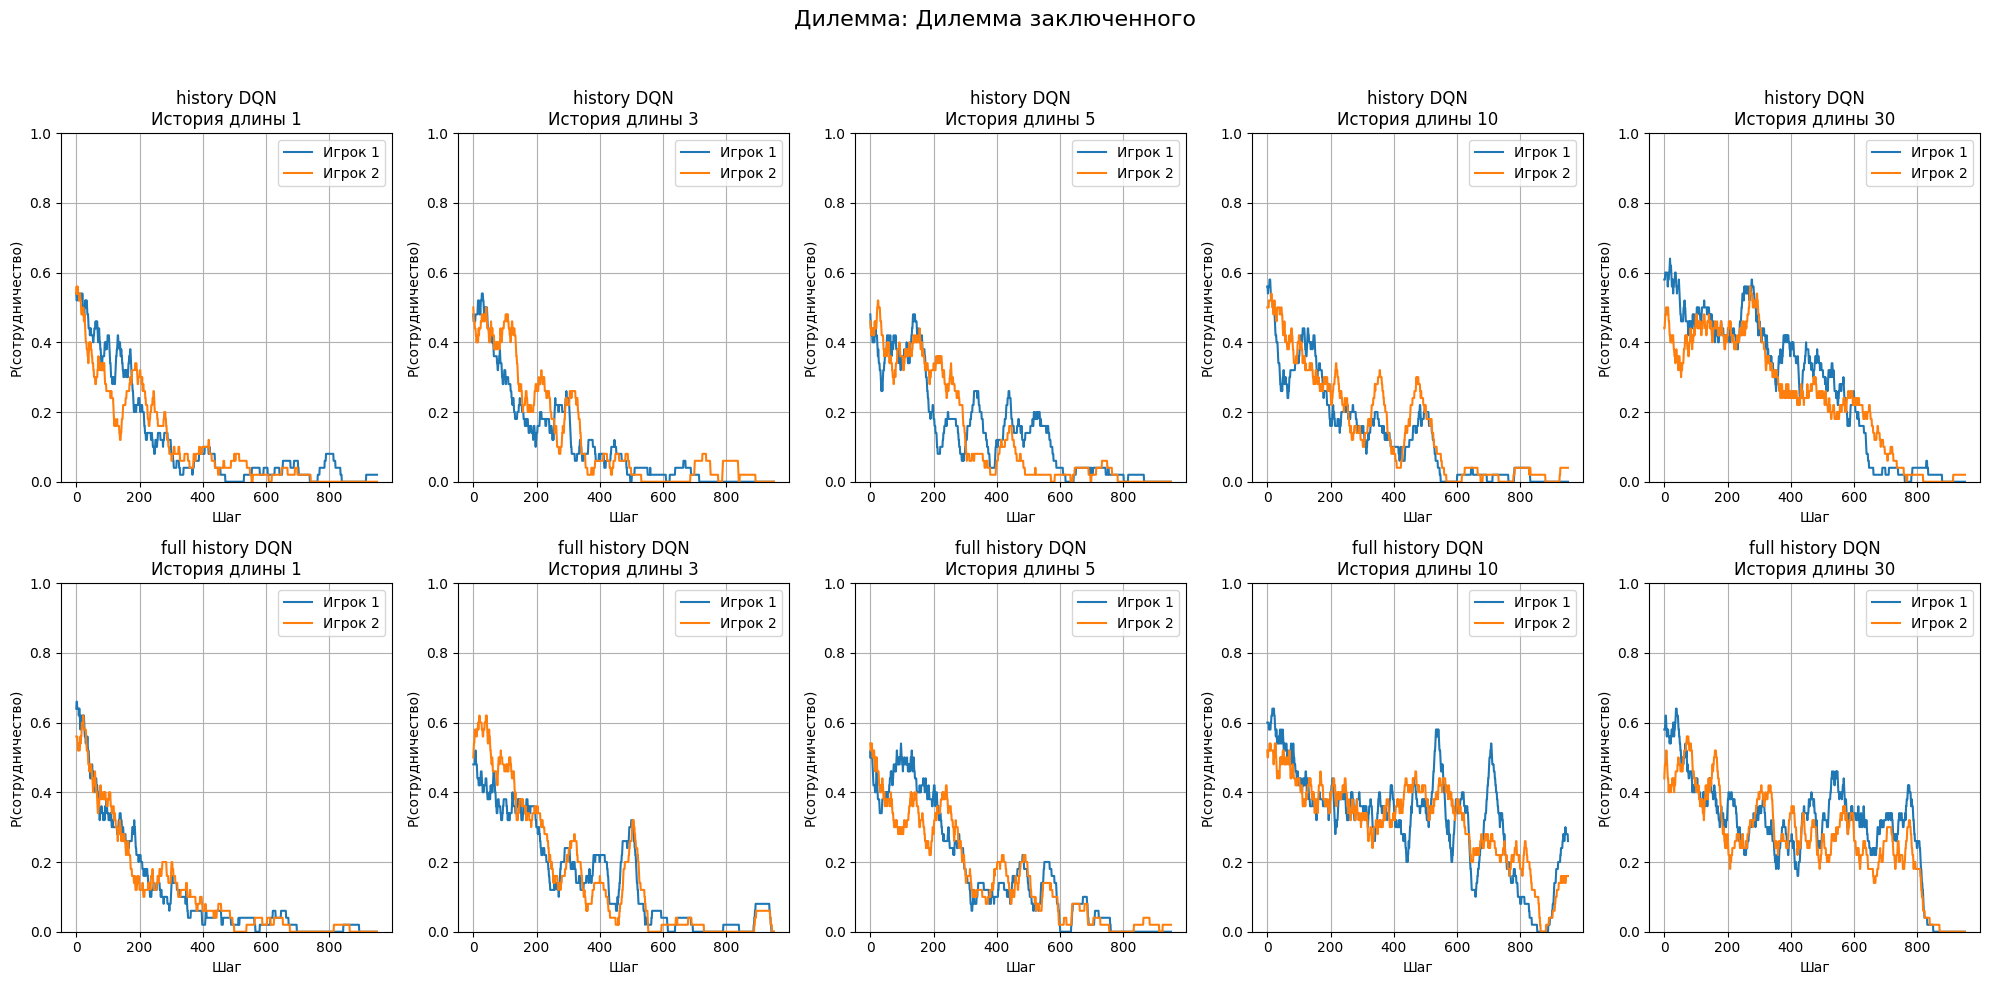

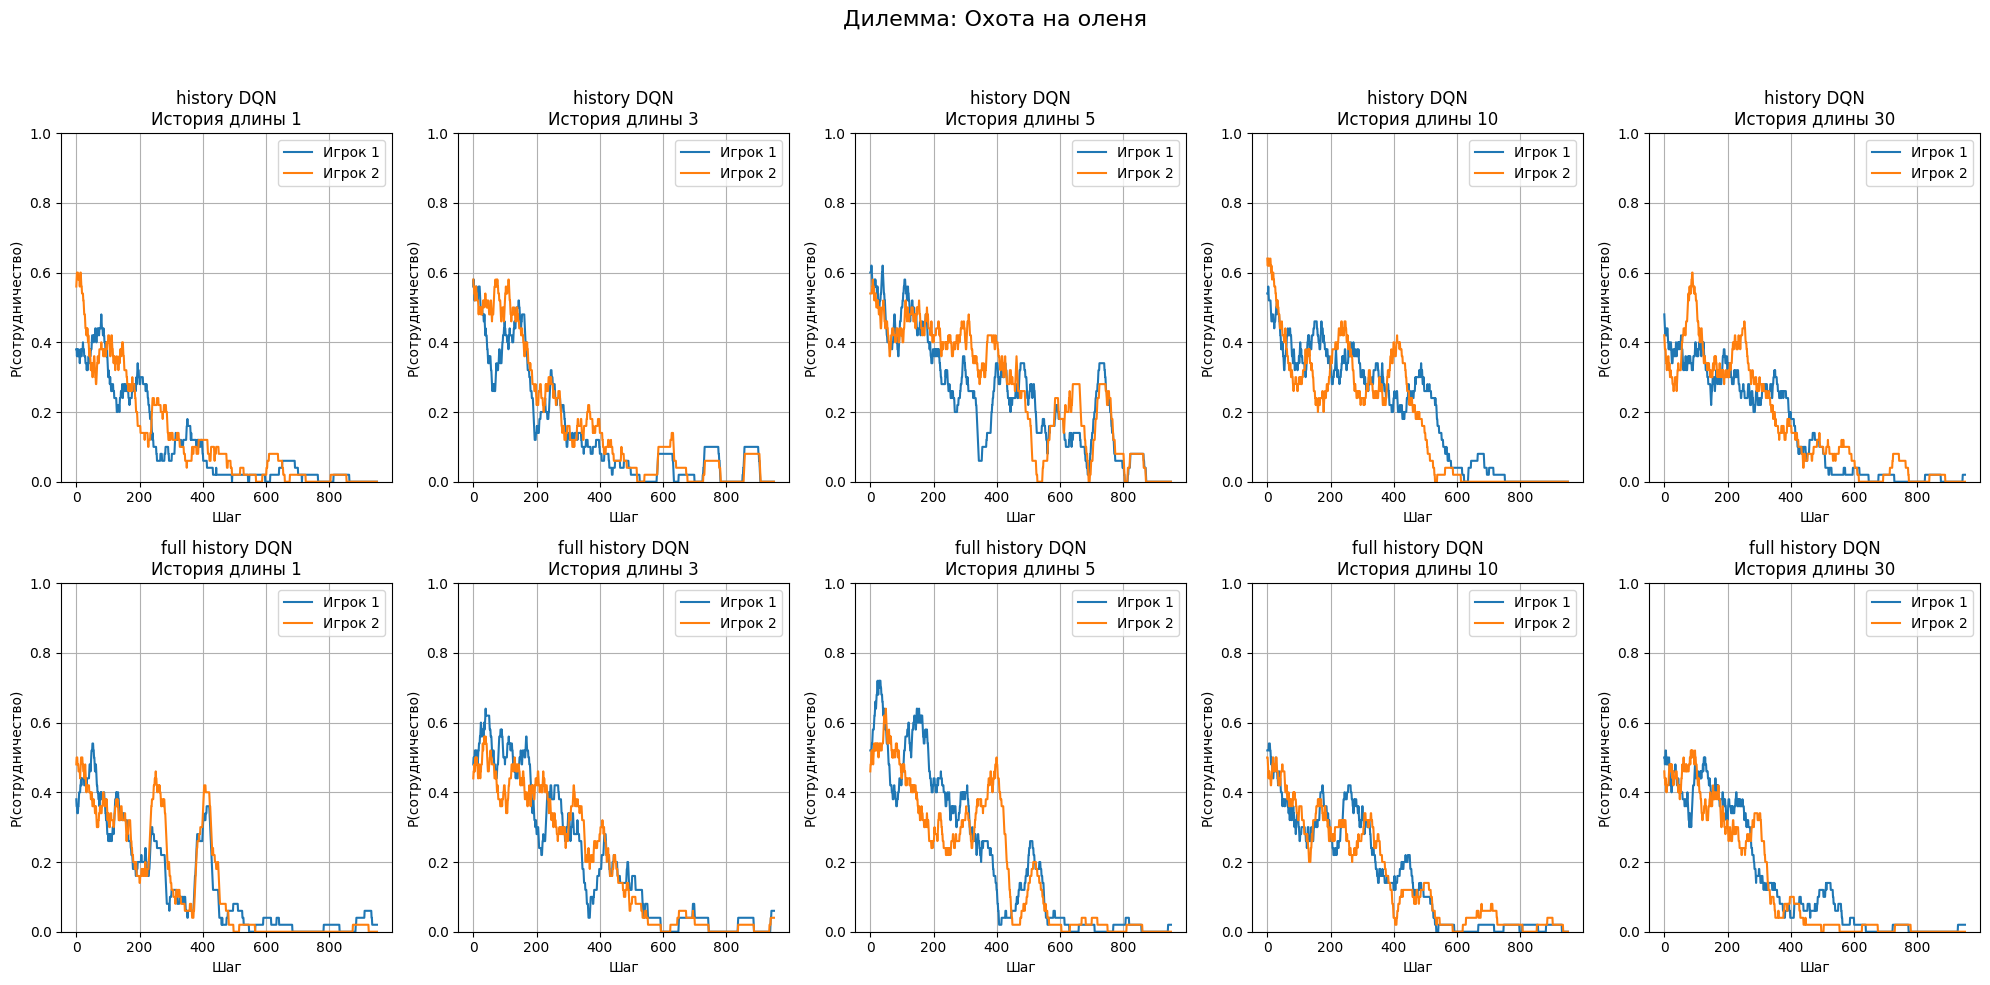

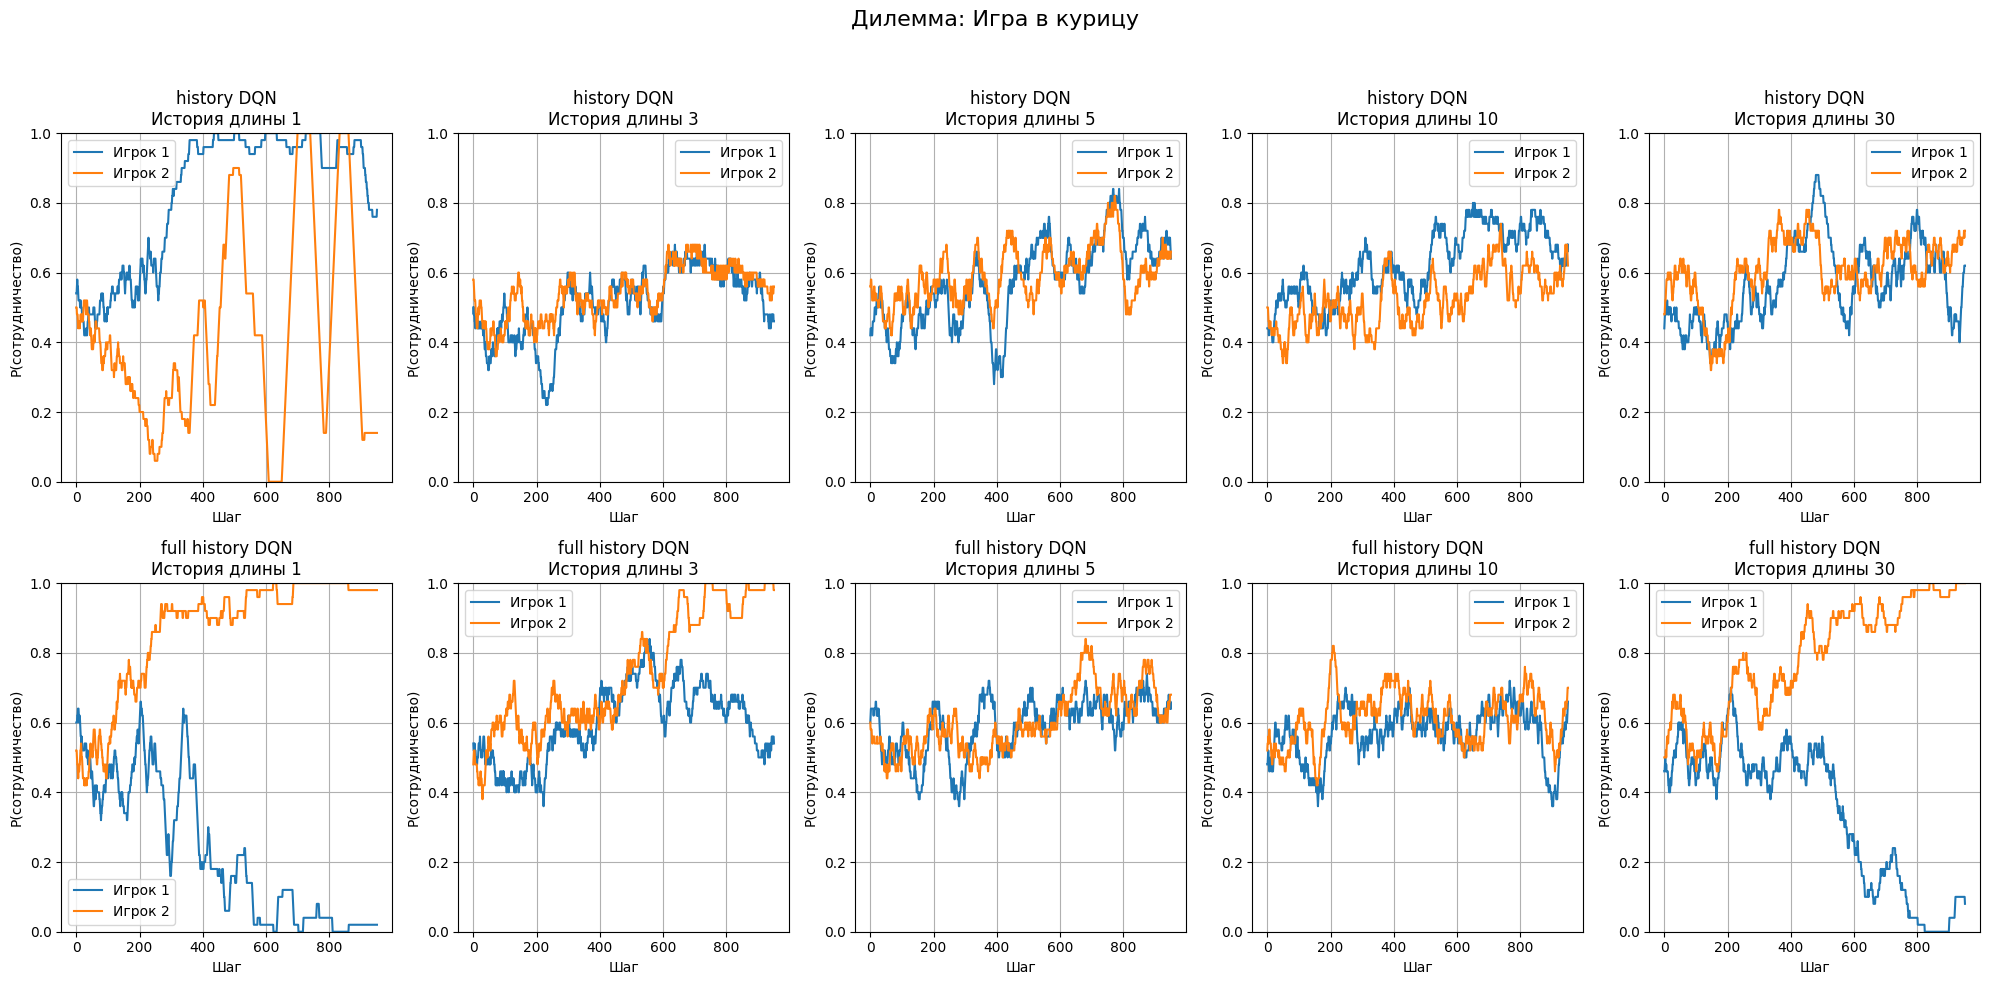

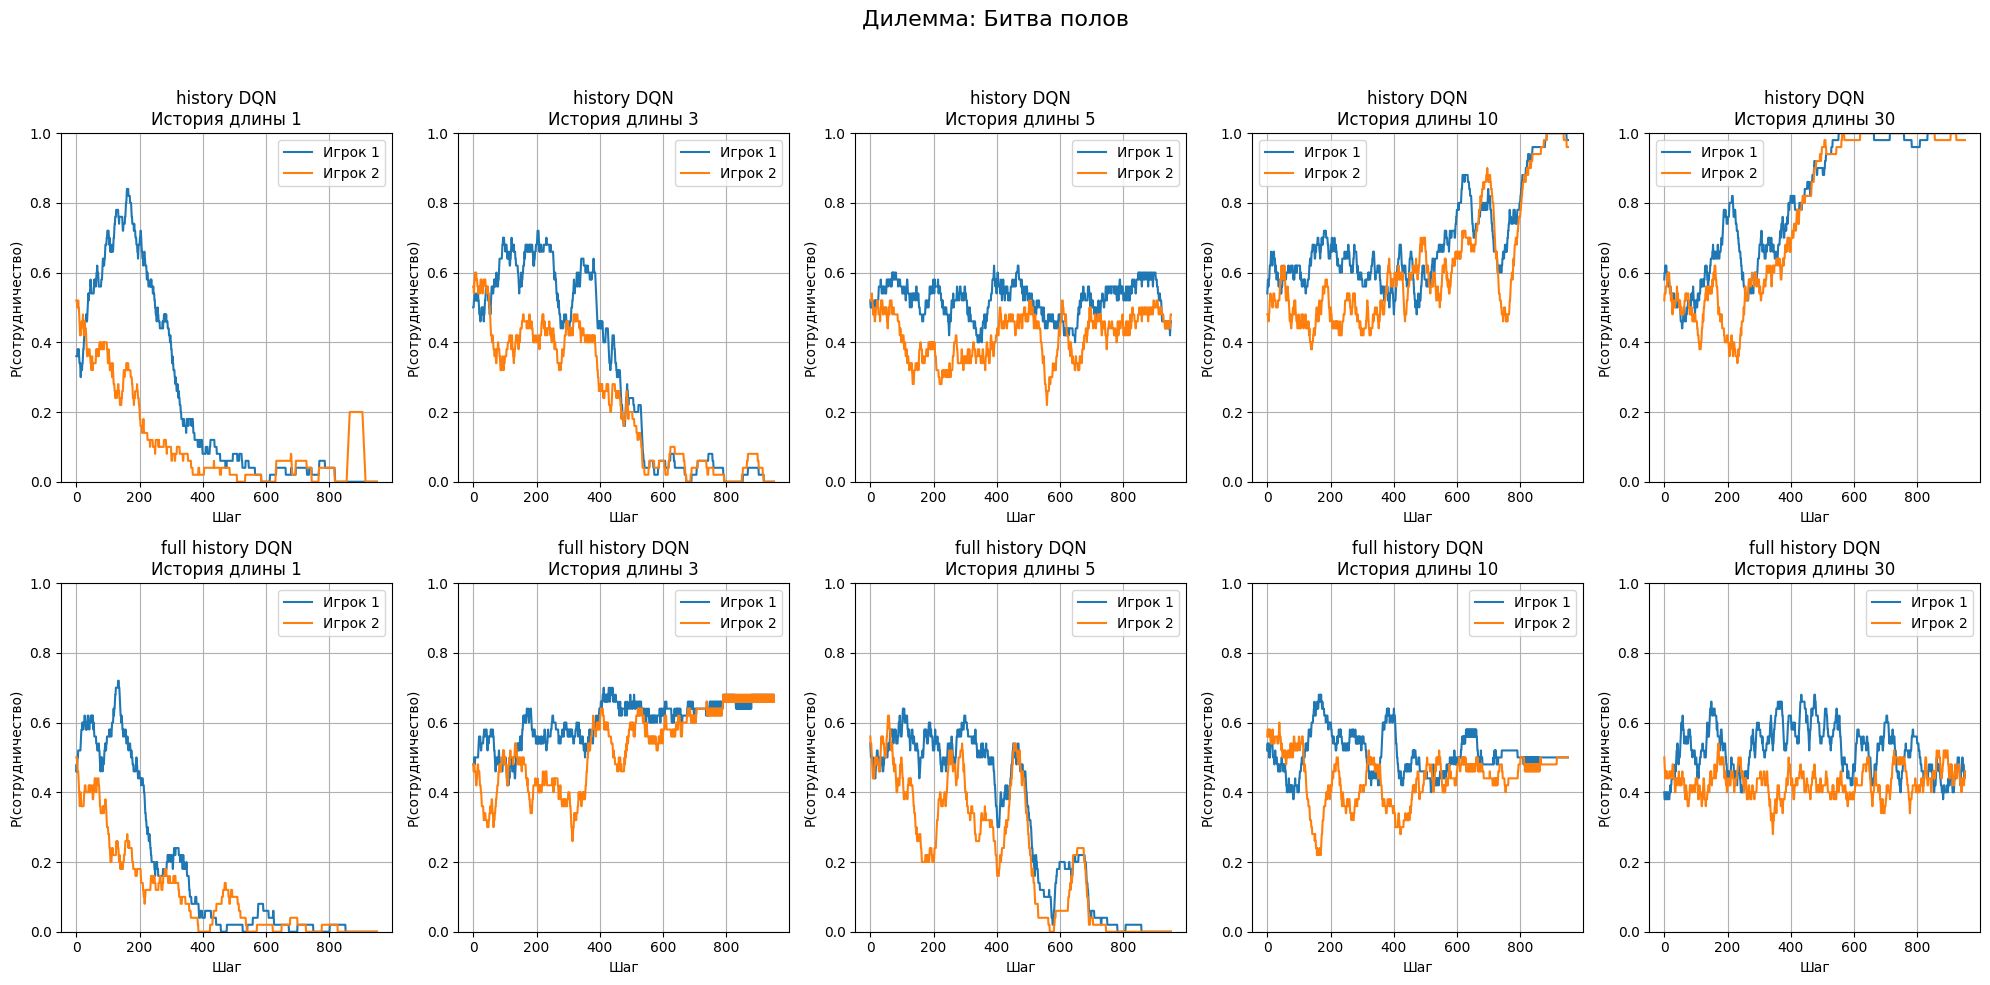

In [32]:
import matplotlib.pyplot as plt

window_names = [f'История длины {h}' for h in history_sizes]

for i, dilemma_name in enumerate(dilemma_names_neural):
    plt.figure(figsize=(20, 10))
    # history_dqn — верхний ряд
    for j, h in enumerate(history_sizes):
        smooth_p1 = smooth(all_train_probs1_hist_by_window[h][i], window_size=50)
        smooth_p2 = smooth(all_train_probs2_hist_by_window[h][i], window_size=50)

        plt.subplot(2, len(history_sizes), j+1)
        plt.plot(smooth_p1, label='Игрок 1')
        plt.plot(smooth_p2, label='Игрок 2')
        plt.title(f'history DQN\n{window_names[j]}')
        plt.xlabel('Шаг')
        plt.ylabel('P(сотрудничество)')
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)

    # full_history_dqn — нижний ряд
    for j, h in enumerate(history_sizes):
        smooth_p1 = smooth(all_train_probs1_fullhist_by_window[h][i], window_size=50)
        smooth_p2 = smooth(all_train_probs2_fullhist_by_window[h][i], window_size=50)

        plt.subplot(2, len(history_sizes), len(history_sizes) + j + 1)
        plt.plot(smooth_p1, label='Игрок 1')
        plt.plot(smooth_p2, label='Игрок 2')
        plt.title(f'full history DQN\n{window_names[j]}')
        plt.xlabel('Шаг')
        plt.ylabel('P(сотрудничество)')
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)

    plt.suptitle(f'Дилемма: {dilemma_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Сохранение результатов

Можно сохранить результаты симуляции для дальнейшего анализа.

In [33]:
import json
import numpy as np

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, (np.ndarray,)):
            return obj.tolist()
        return super().default(obj)

comparison_results = {
    'classic_q': {
        'player1': pd_pol1_y1[-50:],  # последние 50 шагов Q-learning
        'player2': pd_pol2_y1[-50:]
    },
    'history_dqn_train': {
        'player1': all_train_probs1_hist,
        'player2': all_train_probs2_hist
    },
    'full_history_dqn_train': {
        'player1': all_train_probs1_fullhist,
        'player2': all_train_probs2_fullhist
    },
    'history_dqn_by_window': {
        h: {
            'player1': all_train_probs1_hist_by_window[h],
            'player2': all_train_probs2_hist_by_window[h]
        } for h in history_sizes
    },
    'full_history_dqn_by_window': {
        h: {
            'player1': all_train_probs1_fullhist_by_window[h],
            'player2': all_train_probs2_fullhist_by_window[h]
        } for h in history_sizes
    },
    'neural_dilemmas': {
        'types': dilemma_types_neural,
        'names': dilemma_names_neural
    },
    'dilemmas': {
        'types': dilemma_types,
        'names': dilemma_names
    }
}

with open('comparison_results.json', 'w', encoding='utf-8') as f:
    json.dump(comparison_results, f, cls=NpEncoder, ensure_ascii=False, indent=2)

print("Результаты сохранены в файл comparison_results.json")



Результаты сохранены в файл comparison_results.json
